In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uttamkantidutta/amazon-processed/amazon_electronics_processed.csv


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("/kaggle/input/datasets/uttamkantidutta/amazon-processed/amazon_electronics_processed.csv")

df           

,Review_Text,Processed_Text,Sentiment,Product_ID,Product_Category,Rating,Review_Month,Helpful_Votes,Verified_Purchase
0,This is my 3td kindle and I love being able to...,3td kindle love able book,Positive,B07T6XMZQZ,Computers,4,2021-11,0,True
1,Build quality is fine and the Windows 11 came ...,build quality fine window 11 came running micr...,Negative,B0C7KBYGN4,Computers,2,2023-01,0,True
2,Would not connect to my computer even with tec...,not connect computer tech support help,Negative,B09G9STJF6,Computers,1,2023-02,0,True
3,"Like most lenses with bulbous front element, u...",like lens bulbous element using filter not ava...,Positive,B01738GIQG,Camera & Photo,5,2022-05,0,True
4,Work perfectly.,work perfectly,Positive,B000NK5Z8Y,Camera & Photo,5,2016-01,0,True
...,...,...,...,...,...,...,...,...,...
199642,"The sound was good, but I had to return them. ...",sound good return not stay ear hadnt exercised...,Negative,B00WSM6W8W,Home Audio & Theater,2,2014-07,0,True
199643,The laptop is great. Plays just about everyth...,laptop great play just steam account highest r...,Positive,B09J2BCP87,Computers,4,2022-04,1,True
199644,This amplifier is exactly what I was looking f...,amplifier exactly looking small simple powerfu...,Positive,B07Q41YB14,All Electronics,5,2021-01,0,True
199645,My high school son is impressed with everythin...,high school son impressed tool msword function...,Positive,B00FFVYSMK,Computers,5,2014-01,1,True


In [4]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    df["Processed_Text"],
    df["Sentiment"],
    test_size = 0.20,
    random_state = 42,
    stratify = df["Sentiment"]
)

print("Training:", len(X_train))
print("Testing :", len(X_test))

Training: 159717
Testing : 39930


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

y_train

array([2, 2, 0, ..., 1, 2, 0])

In [6]:
sentences_train = X_train.str.split().tolist()

print("Number of sentences:", len(sentences_train))
print("\nExample:")
print(sentences_train[0][:20])

Number of sentences: 159717

Example:
['good', 'cable', 'work']


In [7]:
#Train my own CBOW Word2Vec model

from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences = sentences_train,
    vector_size = 100,
    window = 5,
    min_count = 5,
    workers=4,
    sg=0,
    epochs=10,
    seed=42
)

In [8]:
print("Vocabulary size:", len(w2v_model.wv))

Vocabulary size: 16724


In [9]:
print(w2v_model.wv.index_to_key[:30])

['not', 'great', 'work', 'good', 'use', 'just', 'like', 'product', 'no', 'sound', 'quality', 'time', 'easy', 'love', 'doe', 'case', 'price', 'camera', 'did', 'really', 'bought', 'cable', 'fit', 'im', 'battery', 'need', 'nice', 'tv', 'used', 'little']


In [10]:
vector = w2v_model.wv["battery"]

print(vector)
print("Vector shape:", vector.shape)

[-2.688417    0.05452513  2.6834807  -0.26413435 -0.25150794  0.7195524
 -1.2630616  -0.22636828 -1.0920379  -1.2350903   0.67521423 -4.7467933
  3.2395873   2.5169642  -0.584121    0.30058685  1.0687288   1.6608704
  0.3950662  -1.7892095  -2.8606584  -0.7772681  -2.9962826   3.6251898
 -1.8838115   1.0965065  -0.8542317  -1.2590632   0.5895469   1.038595
 -1.1200792   1.0994942  -0.5821374  -1.5601698   1.7203088   2.418432
 -0.77840245  1.4456682   0.9375872  -4.015471   -1.1678349  -2.2655241
 -4.3475103  -1.7953665   0.9301926   1.9018886  -1.0621039   1.065117
 -0.70927364  0.4702718   0.01507067  1.1626915   2.0828323  -1.6898035
  2.377055    0.8185752   0.18283701  0.732845    0.601625   -4.1421413
 -2.366782    0.04336262  1.0607568  -0.54207367  1.7125742   1.827517
 -2.7245286   2.4064665   0.99321884 -0.55549407  1.2786645  -0.37930548
 -1.1159075  -1.1123228  -0.5288058  -1.7503964  -1.4162971  -0.41901648
 -0.5074022  -1.8937486  -0.4391704   1.2464497  -1.293434   -3.04

In [11]:
w2v_model.wv.most_similar("battery",topn = 10)

[('batter', 0.7838050723075867),
 ('span', 0.6218120455741882),
 ('expectancy', 0.5906953811645508),
 ('aa', 0.5607157349586487),
 ('charge', 0.5513942837715149),
 ('aaa', 0.5488662719726562),
 ('recharge', 0.5485408902168274),
 ('charged', 0.5483711361885071),
 ('nimh', 0.5249451398849487),
 ('shortens', 0.5103053450584412)]

In [12]:
w2v_model.wv.most_similar("sound", topn=10)

[('sounding', 0.7387351393699646),
 ('audio', 0.7126148343086243),
 ('bass', 0.6882062554359436),
 ('sounded', 0.6824638247489929),
 ('vocal', 0.6176159381866455),
 ('separation', 0.6156544089317322),
 ('treble', 0.6125327348709106),
 ('listening', 0.5987903475761414),
 ('anc', 0.5939846038818359),
 ('loudness', 0.5884252786636353)]

In [13]:
w2v_model.wv.most_similar("charger", topn=10)

[('charging', 0.7265074849128723),
 ('charge', 0.7047099471092224),
 ('recharging', 0.5928738713264465),
 ('cord', 0.5680862665176392),
 ('recharge', 0.5571101307868958),
 ('45w', 0.5404887795448303),
 ('charged', 0.5335530638694763),
 ('outlet', 0.5319897532463074),
 ('adaptor', 0.529822587966919),
 ('usbc', 0.5256097912788391)]

In [14]:
w2v_model.wv.similarity("battery", "charger")

np.float32(0.4344161)

In [15]:
w2v_model.wv.similarity("battery", "sound")

np.float32(0.072805695)

In [16]:
#visualize the 100-dimensional vectors

words = [
    "battery",
    "charger",
    "charging",
    "sound",
    "speaker",
    "quality",
    "cable",
    "screen",
    "camera",
    "laptop",
    "keyboard",
    "mouse",
    "product",
    "price",
    "device"
]

# Keep only words that exist in the Word2Vec vocabulary
words = [
    word for word in words
    if word in w2v_model.wv.key_to_index
]

print(words)

['battery', 'charger', 'charging', 'sound', 'speaker', 'quality', 'cable', 'screen', 'camera', 'laptop', 'keyboard', 'mouse', 'product', 'price', 'device']


In [17]:
import numpy as np

embedding_matrix = np.array([
    w2v_model.wv[word]
    for word in words
])

print("Shape:", embedding_matrix.shape)

Shape: (15, 100)


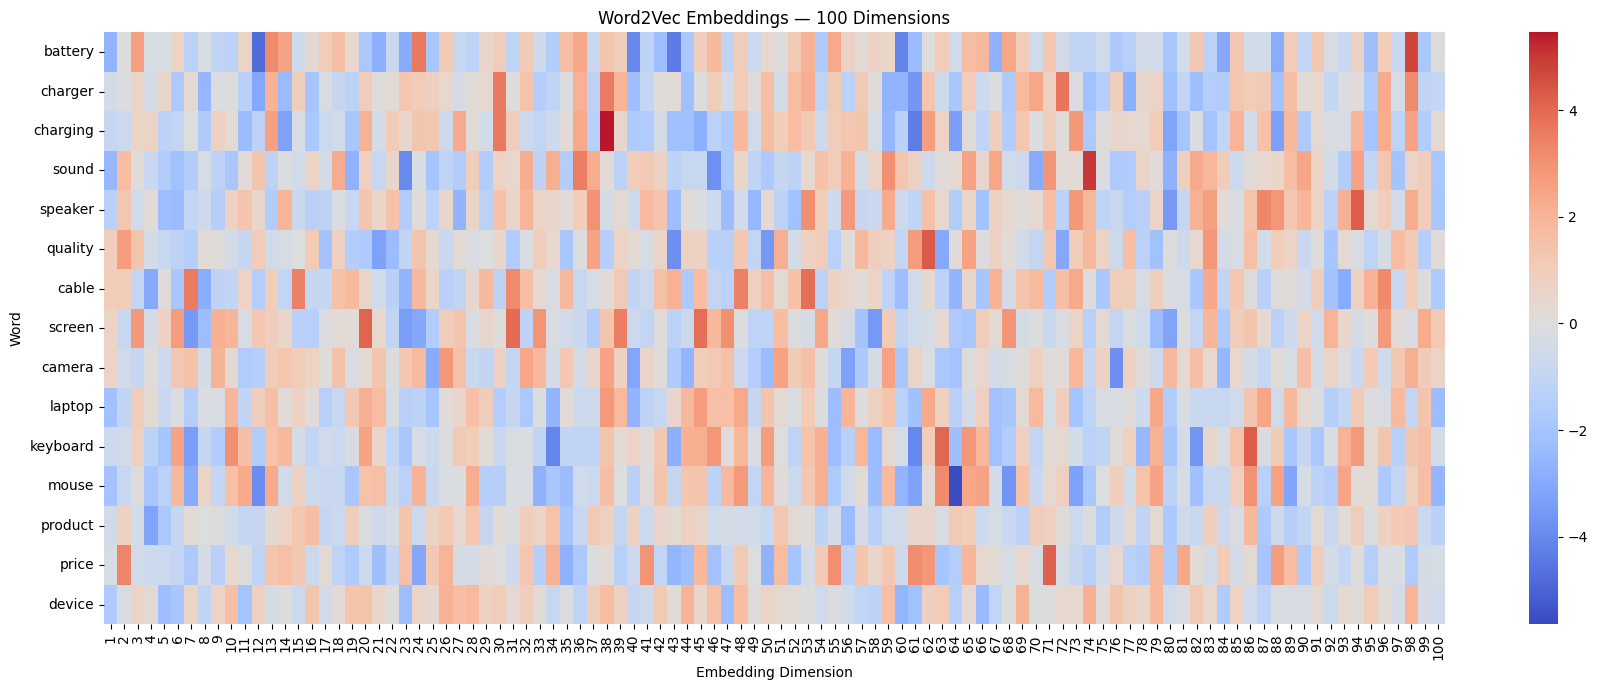

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 7))

sns.heatmap(
    embedding_matrix,
    xticklabels=range(1, 101),
    yticklabels=words,
    cmap="coolwarm",
    center=0
)

plt.title("Word2Vec Embeddings — 100 Dimensions")
plt.xlabel("Embedding Dimension")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

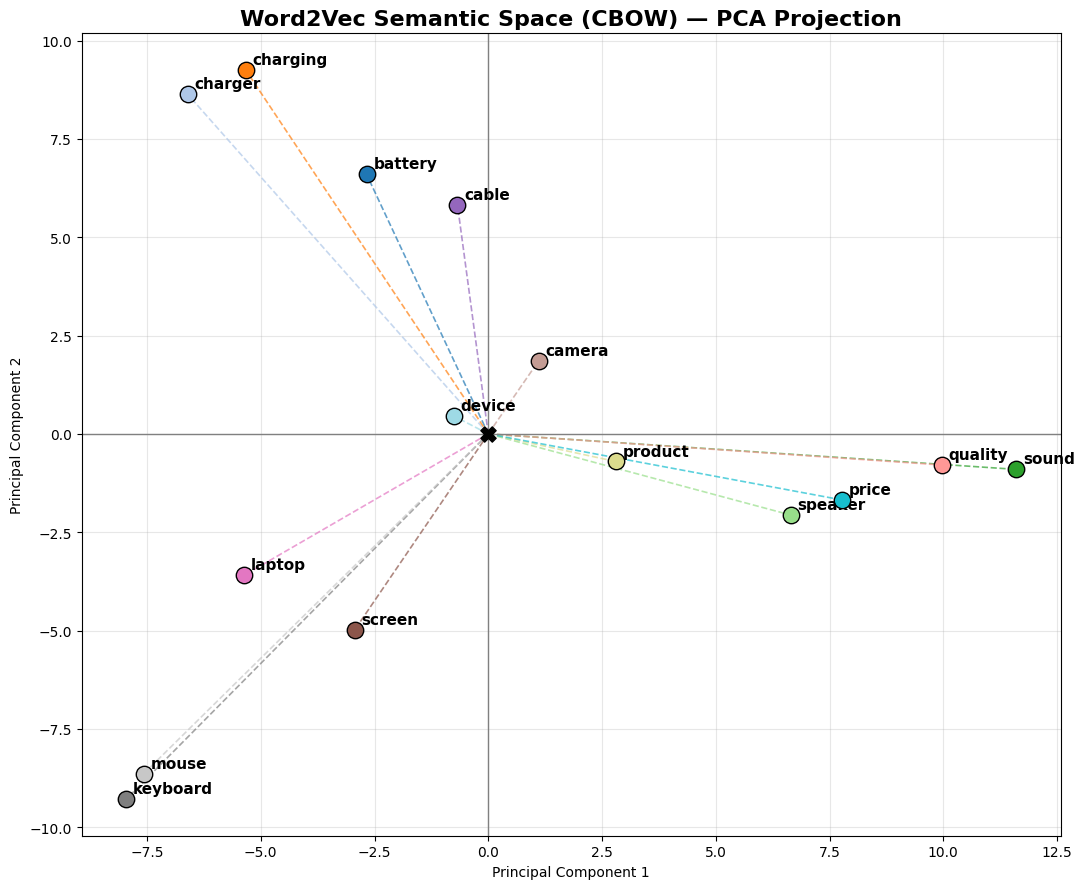

In [19]:
#PCA vusalization of the embeddings

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(embedding_matrix)

plt.figure(figsize=(11,9))

# Different colors
colors = plt.cm.tab20(np.linspace(0,1,len(words)))

# Origin
plt.scatter(0,0,color='black',s=120,marker='X',label='Origin',zorder=5)

for i, word in enumerate(words):

    # line from origin
    plt.plot(
        [0,vectors_2d[i,0]],
        [0,vectors_2d[i,1]],
        linestyle='--',
        linewidth=1.2,
        color=colors[i],
        alpha=0.7
    )

    # point
    plt.scatter(
        vectors_2d[i,0],
        vectors_2d[i,1],
        s=140,
        color=colors[i],
        edgecolor='black',
        zorder=3
    )

    # label
    plt.text(
        vectors_2d[i,0]+0.15,
        vectors_2d[i,1]+0.15,
        word,
        fontsize=11,
        weight='bold'
    )

plt.axhline(0,color='gray',linewidth=1)
plt.axvline(0,color='gray',linewidth=1)

plt.grid(alpha=0.3)
plt.title(
    "Word2Vec Semantic Space (CBOW) — PCA Projection",
    fontsize=16,
    weight='bold'
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

In [20]:
# # ============================================================
# # Word2Vec Embedding Visualization — 3D PCA
# # ============================================================

# from sklearn.decomposition import PCA
# import numpy as np
# import plotly.graph_objects as go

# # ------------------------------------------------------------
# # 1. Reduce 100D Word2Vec vectors → 3D
# # ------------------------------------------------------------

# pca_3d = PCA(n_components=3)

# vectors_3d = pca_3d.fit_transform(embedding_matrix)

# explained_variance = pca_3d.explained_variance_ratio_

# print(f"PC1 explained variance: {explained_variance[0]:.2%}")
# print(f"PC2 explained variance: {explained_variance[1]:.2%}")
# print(f"PC3 explained variance: {explained_variance[2]:.2%}")
# print(f"Total explained variance: {explained_variance.sum():.2%}")


# # ------------------------------------------------------------
# # 2. Create colors
# # ------------------------------------------------------------

# colors = np.arange(len(words))


# # ------------------------------------------------------------
# # 3. Create figure
# # ------------------------------------------------------------

# fig = go.Figure()


# # ------------------------------------------------------------
# # 4. Add arrows from origin → each word
# # ------------------------------------------------------------

# for i, word in enumerate(words):

#     x = vectors_3d[i, 0]
#     y = vectors_3d[i, 1]
#     z = vectors_3d[i, 2]

#     # Line from origin to word
#     fig.add_trace(
#         go.Scatter3d(
#             x=[0, x],
#             y=[0, y],
#             z=[0, z],
#             mode="lines",
#             line=dict(
#                 width=4,
#                 color=f"hsl({i * 360 / len(words)}, 80%, 50%)"
#             ),
#             hoverinfo="skip",
#             showlegend=False
#         )
#     )


# # ------------------------------------------------------------
# # 5. Add word points
# # ------------------------------------------------------------

# fig.add_trace(
#     go.Scatter3d(
#         x=vectors_3d[:, 0],
#         y=vectors_3d[:, 1],
#         z=vectors_3d[:, 2],

#         mode="markers+text",

#         text=words,
#         textposition="top center",

#         marker=dict(
#             size=9,
#             color=colors,
#             colorscale="Turbo",
#             showscale=True,
#             colorbar=dict(
#                 title="Word Index"
#             ),
#             line=dict(
#                 width=1,
#                 color="black"
#             ),
#             opacity=0.95
#         ),

#         hovertemplate=(
#             "<b>%{text}</b><br>"
#             "PC1: %{x:.2f}<br>"
#             "PC2: %{y:.2f}<br>"
#             "PC3: %{z:.2f}"
#             "<extra></extra>"
#         ),

#         name="Words"
#     )
# )


# # ------------------------------------------------------------
# # 6. Add origin
# # ------------------------------------------------------------

# fig.add_trace(
#     go.Scatter3d(
#         x=[0],
#         y=[0],
#         z=[0],

#         mode="markers+text",

#         text=["Origin"],
#         textposition="bottom center",

#         marker=dict(
#             size=12,
#             color="black",
#             symbol="diamond"
#         ),

#         showlegend=False
#     )
# )


# # ------------------------------------------------------------
# # 7. Layout
# # ------------------------------------------------------------

# fig.update_layout(

#     title=dict(
#         text="Interactive 3D Word2Vec Semantic Space — CBOW",
#         x=0.5,
#         font=dict(
#             size=22
#         )
#     ),

#     scene=dict(

#         xaxis=dict(
#             title=f"PC1 ({explained_variance[0]:.1%} variance)",
#             backgroundcolor="white",
#             gridcolor="lightgray",
#             zeroline=True
#         ),

#         yaxis=dict(
#             title=f"PC2 ({explained_variance[1]:.1%} variance)",
#             backgroundcolor="white",
#             gridcolor="lightgray",
#             zeroline=True
#         ),

#         zaxis=dict(
#             title=f"PC3 ({explained_variance[2]:.1%} variance)",
#             backgroundcolor="white",
#             gridcolor="lightgray",
#             zeroline=True
#         ),

#         bgcolor="white"
#     ),

#     width=1100,
#     height=850,

#     margin=dict(
#         l=0,
#         r=0,
#         b=0,
#         t=70
#     )
# )

# import plotly.io as pio

# pio.renderers.default = "iframe"

# fig.show()

In [21]:
from collections import Counter

all_words = [word for sentence in sentences_train for word in sentence ]

word_counts = Counter(all_words)

In [22]:
top_100_words = [
    word 
    for word,count in word_counts.most_common(100)
    if word in w2v_model.wv.key_to_index
]

print("Number of words:", len(top_100_words))
print(top_100_words[:40])

Number of words: 100
['not', 'great', 'work', 'good', 'use', 'just', 'like', 'product', 'no', 'sound', 'quality', 'time', 'easy', 'love', 'doe', 'case', 'price', 'camera', 'did', 'really', 'bought', 'cable', 'fit', 'im', 'battery', 'need', 'nice', 'tv', 'used', 'little', 'using', 'phone', 'better', 'buy', 'device', 'thing', 'got', 'make', 'screen', 'problem']


In [23]:
embedding_matrix_100 = []

for i in top_100_words:
    embedding_matrix_100.append(w2v_model.wv[i])
embedding_matrix_100 = np.array(embedding_matrix_100)

print("Shape:", embedding_matrix_100.shape)
print(embedding_matrix_100)

Shape: (100, 100)
[[-0.77251035  0.6054376   1.1091079  ...  1.1247151   0.23788501
  -1.806007  ]
 [ 1.4401844  -1.424144    1.0950589  ... -1.3987685  -0.24845451
  -0.24530792]
 [ 0.98736334 -1.0325434   0.66719466 ...  0.21413295  1.185136
  -1.4498694 ]
 ...
 [-0.36107287 -1.939498    2.465083   ...  1.1166095   2.0615456
  -1.614638  ]
 [ 1.6310828  -1.1299629   0.4108811  ... -0.10156197 -0.06265175
  -1.9026357 ]
 [-1.0461723  -3.1726046  -1.5572276  ...  0.02464025  2.94659
   0.42264602]]


PC1 explained variance: 7.07%
PC2 explained variance: 5.67%
Total explained variance: 12.74%


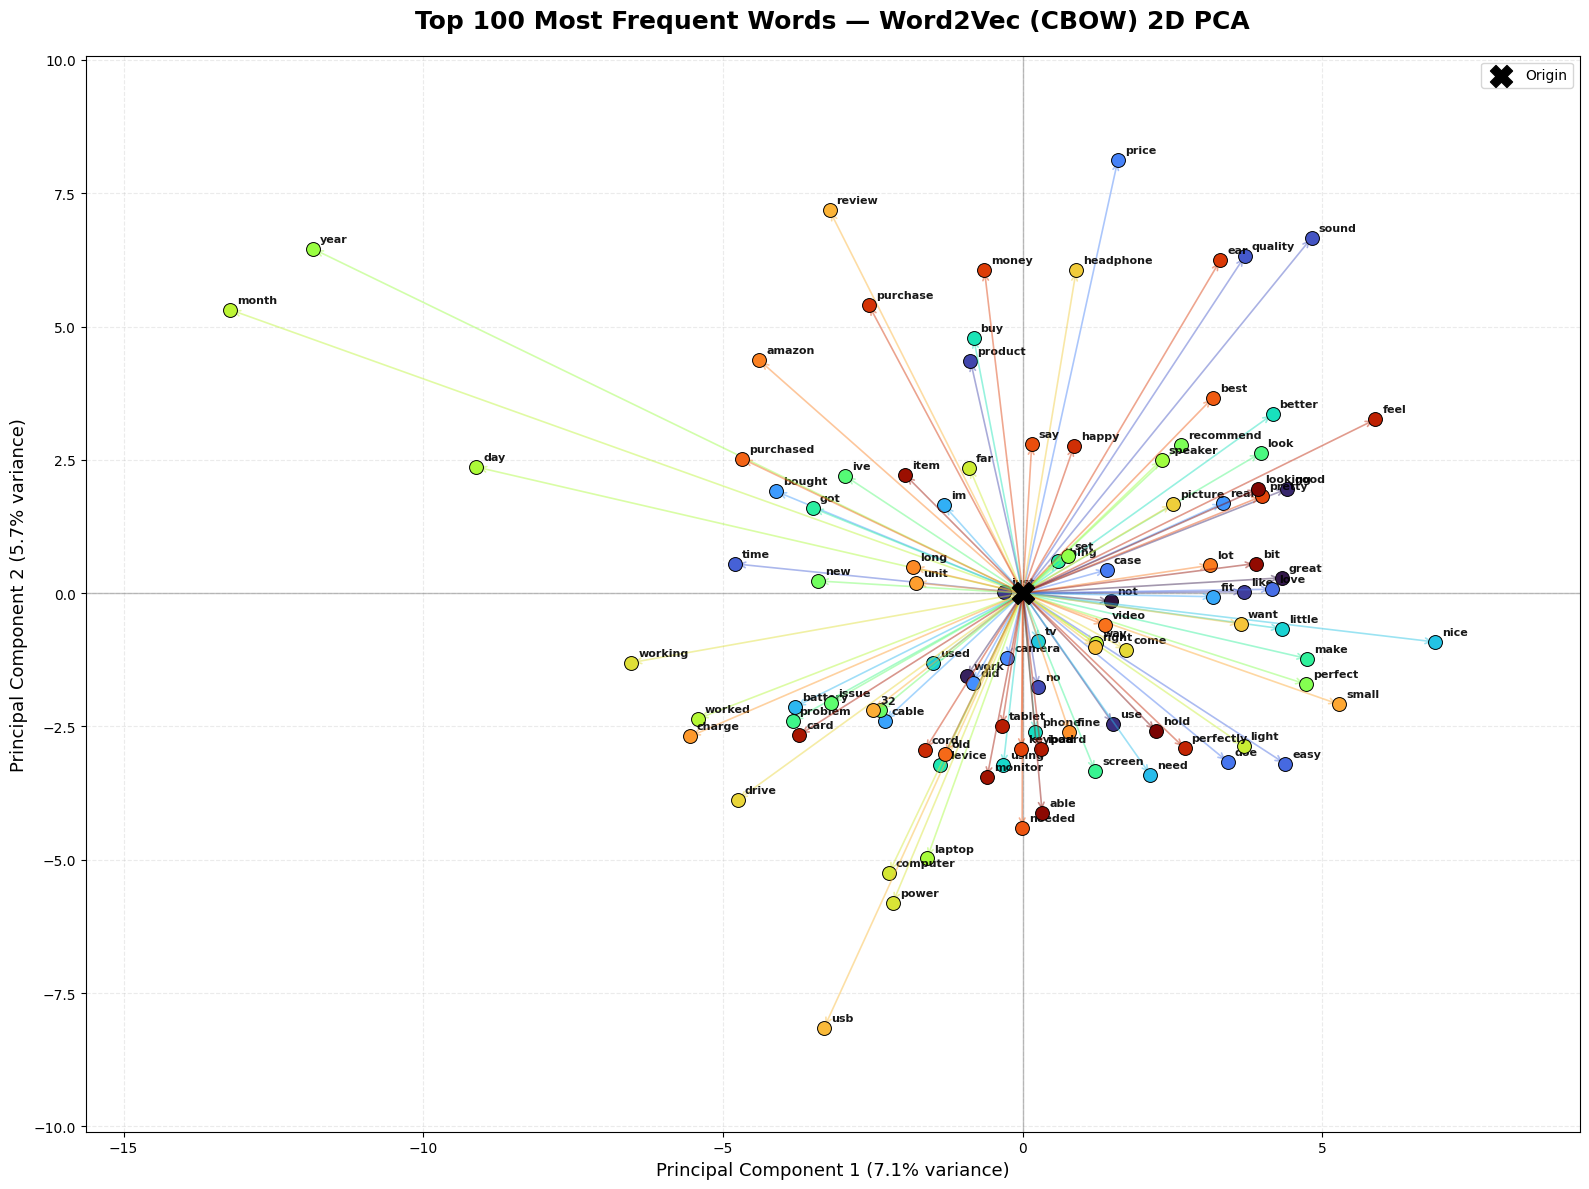

In [24]:
# ============================================================
# Word2Vec — Top 100 Words | 2D PCA Visualization
# ============================================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. PCA: 100 dimensions → 2 dimensions
# ------------------------------------------------------------

pca_100 = PCA(n_components=2)

vectors_100_2d = pca_100.fit_transform(
    embedding_matrix_100
)

explained_variance = pca_100.explained_variance_ratio_

print(f"PC1 explained variance: {explained_variance[0]:.2%}")
print(f"PC2 explained variance: {explained_variance[1]:.2%}")
print(f"Total explained variance: {explained_variance.sum():.2%}")


# ------------------------------------------------------------
# 2. Colors for the 100 words
# ------------------------------------------------------------

colors = plt.cm.turbo(
    np.linspace(0, 1, len(top_100_words))
)


# ------------------------------------------------------------
# 3. Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 12))


# ------------------------------------------------------------
# 4. Plot arrows + points + labels
# ------------------------------------------------------------

for i, word in enumerate(top_100_words):

    x = vectors_100_2d[i, 0]
    y = vectors_100_2d[i, 1]

    # Arrow from origin to embedding position
    ax.annotate(
        "",
        xy=(x, y),
        xytext=(0, 0),
        arrowprops=dict(
            arrowstyle="->",
            color=colors[i],
            linewidth=1.2,
            alpha=0.45
        )
    )

    # Word point
    ax.scatter(
        x,
        y,
        s=100,
        color=colors[i],
        edgecolor="black",
        linewidth=0.7,
        zorder=3
    )

    # Word label
    ax.annotate(
        word,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
        alpha=0.9
    )


# ------------------------------------------------------------
# 5. Origin
# ------------------------------------------------------------

ax.scatter(
    0,
    0,
    s=250,
    color="black",
    marker="X",
    zorder=5,
    label="Origin"
)


# ------------------------------------------------------------
# 6. Axes
# ------------------------------------------------------------

ax.axhline(
    0,
    color="gray",
    linewidth=1,
    alpha=0.5
)

ax.axvline(
    0,
    color="gray",
    linewidth=1,
    alpha=0.5
)


# ------------------------------------------------------------
# 7. Formatting
# ------------------------------------------------------------

ax.set_title(
    "Top 100 Most Frequent Words — Word2Vec (CBOW) 2D PCA",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    f"Principal Component 1 "
    f"({explained_variance[0]:.1%} variance)",
    fontsize=13
)

ax.set_ylabel(
    f"Principal Component 2 "
    f"({explained_variance[1]:.1%} variance)",
    fontsize=13
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.25
)

ax.legend()

ax.margins(0.12)

plt.tight_layout()
plt.show()

In [25]:
w2v_model.wv.most_similar(["good"],topn = 10)

[('decent', 0.8389260172843933),
 ('great', 0.8104375004768372),
 ('excellent', 0.7265918850898743),
 ('awesome', 0.6628473401069641),
 ('nice', 0.6614580750465393),
 ('fantastic', 0.6361121535301208),
 ('ok', 0.6352428793907166),
 ('impressive', 0.6288314461708069),
 ('better', 0.6039322018623352),
 ('bad', 0.6008750796318054)]

In [26]:
w2v_model.wv.most_similar(["worst"],topn = 10)

[('best', 0.6883862614631653),
 ('ive', 0.5177832245826721),
 ('terrible', 0.5098109841346741),
 ('awful', 0.4943186342716217),
 ('past', 0.4918704032897949),
 ('horrible', 0.4903711676597595),
 ('garbage', 0.4887145161628723),
 ('worse', 0.4701620638370514),
 ('never', 0.45579764246940613),
 ('coolest', 0.44865304231643677)]

In [27]:
w2v_model.save("amazon_electronics_cbow_word2vec.model")

In [28]:
from gensim.models import Word2Vec

test_model = Word2Vec.load(
    "amazon_electronics_cbow_word2vec.model"
)

print("Vocabulary size:", len(test_model.wv))
print("Vector size:", test_model.wv.vector_size)

Vocabulary size: 16724
Vector size: 100


In [29]:
w2v_model.wv.save_word2vec_format(
    "amazon_electronics_cbow_vectors.txt",
    binary=False
)

#WORD_2_VEC is done here 

In [30]:
# Word2Vec vocabulary to Integer encoding here
word_to_index = {
    word: idx + 1
    for idx, word in enumerate(w2v_model.wv.index_to_key)
}

print("Vocabulary size:", len(word_to_index))

# Check a few words
for word in ["battery", "charger", "sound", "quality"]:
    if word in word_to_index:
        print(word, "→", word_to_index[word])

Vocabulary size: 16724
battery → 25
charger → 143
sound → 10
quality → 11


In [31]:
def text_to_sequence(text):
    return [
        word_to_index[word]
        for word in str(text).split()
        if word in word_to_index
    ]

X_train_seq = X_train.apply(text_to_sequence)
X_test_seq = X_test.apply(text_to_sequence)

print(X_train_seq.iloc[0])

[4, 22, 3]


In [32]:
import numpy as np

train_lengths = X_train_seq.apply(len)

print(train_lengths.describe())

print("\nPercentiles:")
print(
    train_lengths.quantile(
        [0.90, 0.95, 0.99, 0.995, 0.999]
    )
)

count    159717.000000
mean         20.848019
std          34.422842
min           0.000000
25%           5.000000
50%          11.000000
75%          24.000000
max        1818.000000
Name: Processed_Text, dtype: float64

Percentiles:
0.900     47.000
0.950     71.000
0.990    157.000
0.995    208.000
0.999    367.284
Name: Processed_Text, dtype: float64


In [33]:
#padding
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 100

X_train_padded = pad_sequences(
    X_train_seq.tolist(),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_seq.tolist(),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train_padded.shape)
print("Testing shape :", X_test_padded.shape)

Training shape: (159717, 100)
Testing shape : (39930, 100)


In [34]:
#Word2vec embedding matrix
import numpy as np

vocab_size = len(word_to_index) + 1
embedding_dim = w2v_model.wv.vector_size

embedding_matrix = np.zeros(
    (vocab_size, embedding_dim),
    dtype=np.float32
)

for word, index in word_to_index.items():

    embedding_matrix[index] = w2v_model.wv[word]

print("Vocabulary size:", vocab_size)
print("Embedding dimension:", embedding_dim)
print("Embedding matrix shape:", embedding_matrix.shape)

Vocabulary size: 16725
Embedding dimension: 100
Embedding matrix shape: (16725, 100)


In [35]:
word = "battery"

idx = word_to_index[word]

print("Word:", word)
print("Index:", idx)

print("\nWord2Vec vector:")
print(w2v_model.wv[word][:10])

print("\nEmbedding matrix vector:")
print(embedding_matrix[idx][:10])

Word: battery
Index: 25

Word2Vec vector:
[-2.688417    0.05452513  2.6834807  -0.26413435 -0.25150794  0.7195524
 -1.2630616  -0.22636828 -1.0920379  -1.2350903 ]

Embedding matrix vector:
[-2.688417    0.05452513  2.6834807  -0.26413435 -0.25150794  0.7195524
 -1.2630616  -0.22636828 -1.0920379  -1.2350903 ]


# ***NN Training parts starts from Here***

In [36]:
#Actuall Neural Network mannn 

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding , SimpleRNN,LSTM,GRU,Bidirectional, Dense, Dropout

# **SimpleRNN + Word2Vec(Frozen)**

In [37]:
#SimpleRNN + Word2Vec

from tensorflow.keras.layers import Input

NUM_CLASSES = 3 

#Simple RNN
rnn_model = Sequential([
    Input(shape=(MAX_LEN,)), 
    Embedding(
        input_dim=vocab_size, 
        output_dim=embedding_dim,
        weights = [embedding_matrix],
        mask_zero=True, 
        trainable=False
    ),
    SimpleRNN(128, dropout=0.2, recurrent_dropout=0.2),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

rnn_model.compile(
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)
rnn_model.summary()

I0000 00:00:1787173893.508917      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787173893.512261      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     1,672,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        29,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,702,199 (6.49 MB)

 Trainable params: 29,699 (116.01 KB)

 Non-trainable params: 1,672,500 (6.38 MB)

In [38]:
import tensorflow as tf

early_stopping_rnn = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [39]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate balanced class weights
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert the weights array into a dictionary format that Keras requires
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.9213612905554152), 1: np.float64(5.111761881901105), 2: np.float64(0.43784592863076)}


In [40]:
history_rnn = rnn_model.fit(
    X_train_padded,
    y_train,
    
    validation_split=0.10,
    
    epochs=10,
    batch_size=128,
    
    class_weight=class_weights,
    
    callbacks=[early_stopping_rnn],
    
    verbose=1
)

Epoch 1/10
  15/1124 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.3338 - loss: 1.4257

I0000 00:00:1787173899.786431     186 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1124/1124 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6416 - loss: 0.9336 - val_accuracy: 0.6779 - val_loss: 0.7238
Epoch 2/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6766 - loss: 0.8401 - val_accuracy: 0.7167 - val_loss: 0.6782
Epoch 3/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.6770 - loss: 0.8337 - val_accuracy: 0.7098 - val_loss: 0.6879
Epoch 4/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.6709 - loss: 0.8418 - val_accuracy: 0.7104 - val_loss: 0.7144


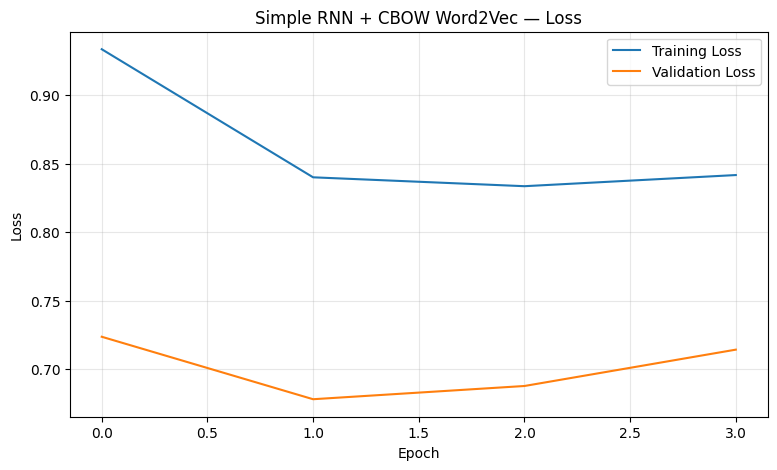

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    history_rnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_rnn.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Simple RNN + CBOW Word2Vec — Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

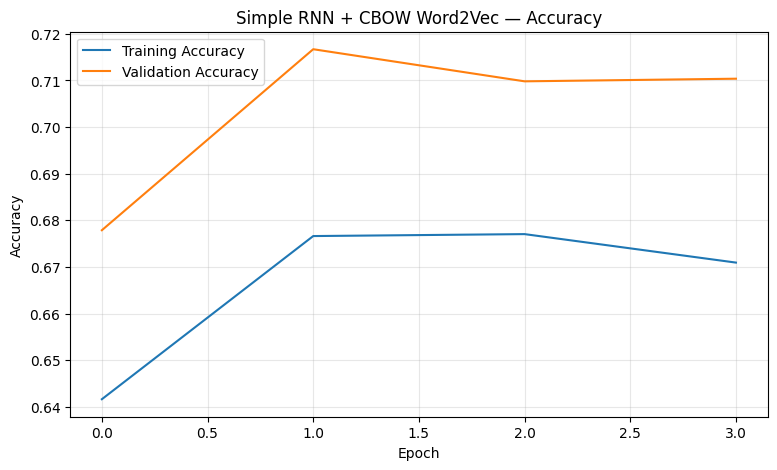

In [42]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_rnn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_rnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Simple RNN + CBOW Word2Vec — Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# **LSTM + Word2Vec**

In [43]:
#LSTM + Word2Vec

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense

lstm_model = Sequential([
    
    Input(shape=(MAX_LEN,)),

    # Pre-trained CBOW Word2Vec embeddings
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=False
    ),

    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 100)       │     1,672,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,790,135 (6.83 MB)

 Trainable params: 117,635 (459.51 KB)

 Non-trainable params: 1,672,500 (6.38 MB)

In [44]:
early_stopping_lstm = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_padded,
    y_train,

    validation_split=0.10,

    epochs=10,
    batch_size=128,

    class_weight=class_weights,

    callbacks=[early_stopping_lstm],

    verbose=1
)

Epoch 1/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 383s 335ms/step - accuracy: 0.7170 - loss: 0.7666 - val_accuracy: 0.7869 - val_loss: 0.5239
Epoch 2/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 378s 336ms/step - accuracy: 0.7556 - loss: 0.6974 - val_accuracy: 0.8067 - val_loss: 0.5029
Epoch 3/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 376s 335ms/step - accuracy: 0.7691 - loss: 0.6696 - val_accuracy: 0.7926 - val_loss: 0.5223
Epoch 4/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 378s 336ms/step - accuracy: 0.7771 - loss: 0.6525 - val_accuracy: 0.7749 - val_loss: 0.5539


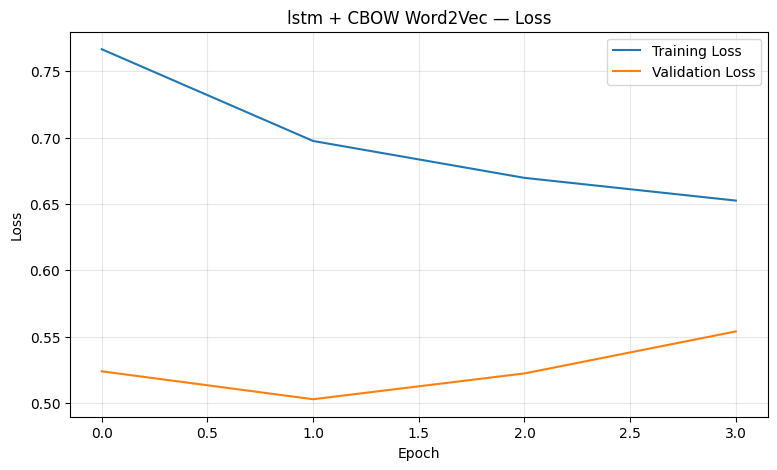

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    history_lstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_lstm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("lstm + CBOW Word2Vec — Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

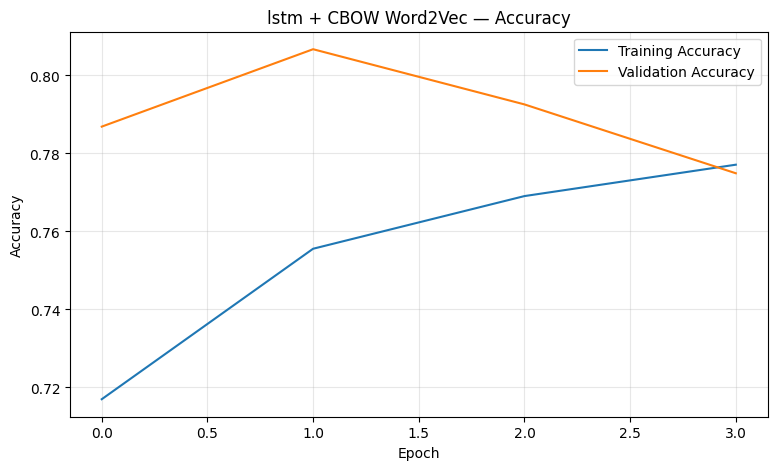

In [46]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_lstm.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_lstm.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("lstm + CBOW Word2Vec — Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# **GRU + Word2Vec**

In [47]:
# ============================================================
# GRU + Word2Vec
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    GRU,
    Dropout,
    Dense
)

gru_model = Sequential([

    Input(shape=(MAX_LEN,)),

    # Pre-trained CBOW Word2Vec embeddings
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=False
    ),

    GRU(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

gru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 100)       │     1,672,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,761,207 (6.72 MB)

 Trainable params: 88,707 (346.51 KB)

 Non-trainable params: 1,672,500 (6.38 MB)

In [48]:
early_stopping_gru = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_gru = gru_model.fit(
    X_train_padded,
    y_train,

    validation_split=0.10,

    epochs=10,
    batch_size=128,

    class_weight=class_weights,

    callbacks=[early_stopping_gru],

    verbose=1
)

Epoch 1/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 332s 292ms/step - accuracy: 0.7075 - loss: 0.7877 - val_accuracy: 0.7533 - val_loss: 0.5881
Epoch 2/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 329s 292ms/step - accuracy: 0.7562 - loss: 0.6990 - val_accuracy: 0.7496 - val_loss: 0.5982
Epoch 3/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 328s 292ms/step - accuracy: 0.7681 - loss: 0.6737 - val_accuracy: 0.7902 - val_loss: 0.5237
Epoch 4/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 329s 292ms/step - accuracy: 0.7749 - loss: 0.6591 - val_accuracy: 0.7815 - val_loss: 0.5521
Epoch 5/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 329s 293ms/step - accuracy: 0.7824 - loss: 0.6470 - val_accuracy: 0.7750 - val_loss: 0.5629


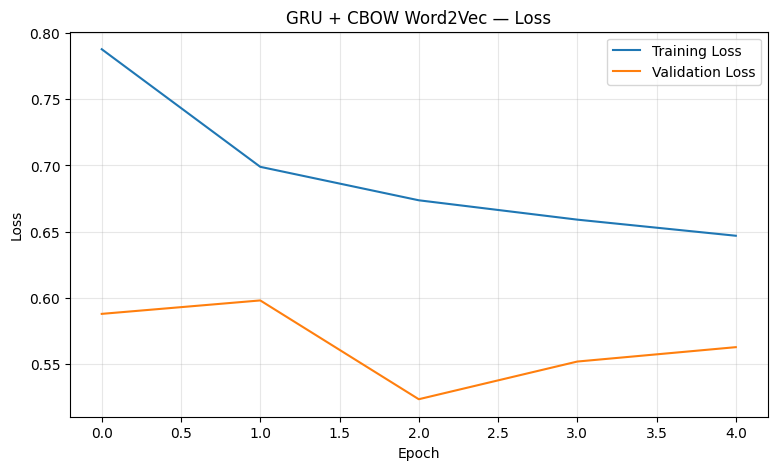

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    history_gru.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_gru.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU + CBOW Word2Vec — Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

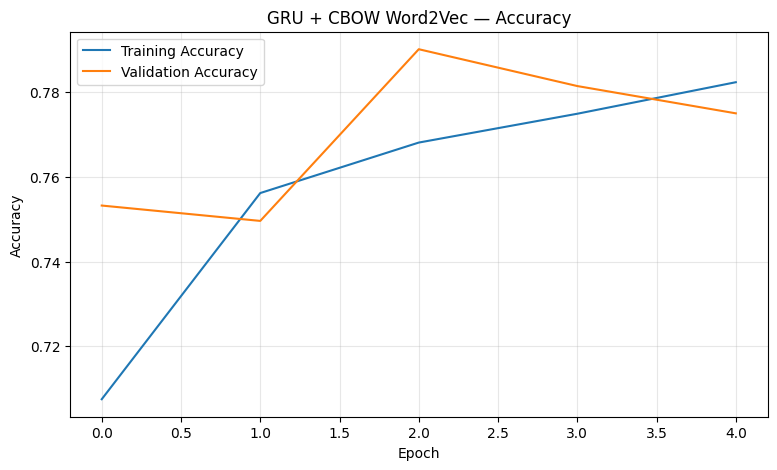

In [50]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_gru.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_gru.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU + CBOW Word2Vec — Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# **BiLSTM + Word2Vec**

In [51]:
# ============================================================
# BiLSTM + Word2Vec
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Bidirectional,
    Dropout,
    Dense
)

bilstm_model = Sequential([

    Input(shape=(MAX_LEN,)),

    # Pre-trained CBOW Word2Vec embeddings
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=False
    ),

    Bidirectional(
        LSTM(
            128,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

bilstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 100)       │     1,672,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,907,767 (7.28 MB)

 Trainable params: 235,267 (919.01 KB)

 Non-trainable params: 1,672,500 (6.38 MB)

In [52]:
early_stopping_bilstm = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_bilstm = bilstm_model.fit(
    X_train_padded,
    y_train,

    validation_split=0.10,

    epochs=10,
    batch_size=128,

    class_weight=class_weights,

    callbacks=[early_stopping_bilstm],

    verbose=1
)

Epoch 1/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 629s 553ms/step - accuracy: 0.7339 - loss: 0.7376 - val_accuracy: 0.7804 - val_loss: 0.5500
Epoch 2/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 625s 556ms/step - accuracy: 0.7681 - loss: 0.6752 - val_accuracy: 0.7756 - val_loss: 0.5545
Epoch 3/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 638s 568ms/step - accuracy: 0.7807 - loss: 0.6490 - val_accuracy: 0.8031 - val_loss: 0.4871
Epoch 4/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 647s 575ms/step - accuracy: 0.7892 - loss: 0.6268 - val_accuracy: 0.7814 - val_loss: 0.5548
Epoch 5/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 650s 578ms/step - accuracy: 0.7932 - loss: 0.6094 - val_accuracy: 0.8086 - val_loss: 0.4802
Epoch 6/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 631s 561ms/step - accuracy: 0.8008 - loss: 0.5915 - val_accuracy: 0.7962 - val_loss: 0.5054
Epoch 7/10
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 624s 555ms/step - accuracy: 0.8062 - loss: 0.5741 - val_accuracy: 0.8135 - val_loss: 0.4816


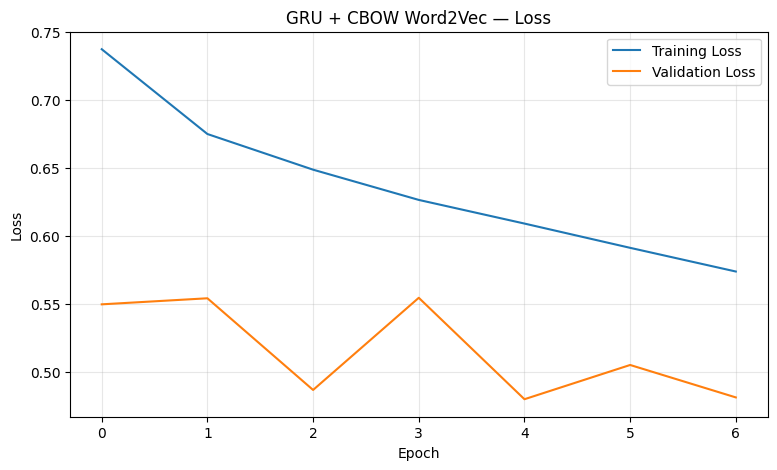

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    history_bilstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_bilstm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU + CBOW Word2Vec — Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

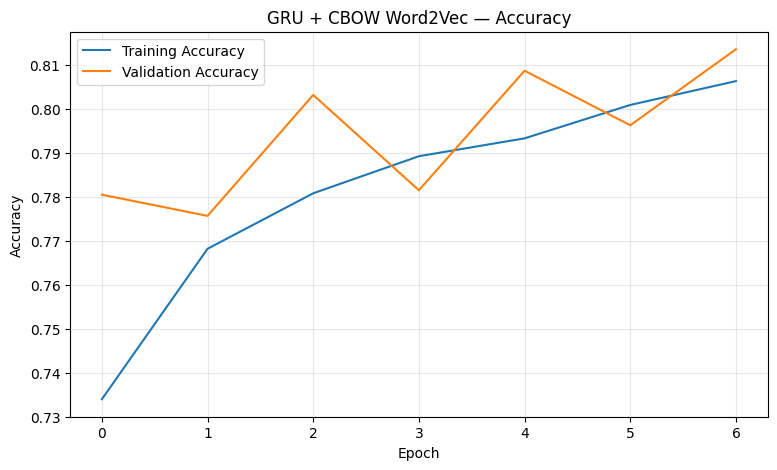

In [56]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_bilstm.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_bilstm.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU + CBOW Word2Vec — Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [57]:
print("RNN epochs run:", len(history_rnn.history["loss"]))
print("LSTM epochs run:", len(history_lstm.history["loss"]))
print("GRU epochs run:", len(history_gru.history["loss"]))
print("BiLSTM epochs run:", len(history_bilstm.history["loss"]))

RNN epochs run: 4
LSTM epochs run: 4
GRU epochs run: 5
BiLSTM epochs run: 7


In [58]:
import numpy as np

histories = {
    "Simple RNN": history_rnn,
    "LSTM": history_lstm,
    "GRU": history_gru,
    "BiLSTM": history_bilstm
}

for name, history in histories.items():

    best_epoch = np.argmin(history.history["val_loss"]) + 1
    best_val_loss = np.min(history.history["val_loss"])
    best_val_acc = history.history["val_accuracy"][best_epoch - 1]

    print(f"\n{name}")
    print(f"Best Epoch        : {best_epoch}")
    print(f"Best Validation Loss : {best_val_loss:.4f}")
    print(f"Validation Accuracy  : {best_val_acc:.4f}")


Simple RNN
Best Epoch        : 2
Best Validation Loss : 0.6782
Validation Accuracy  : 0.7167

LSTM
Best Epoch        : 2
Best Validation Loss : 0.5029
Validation Accuracy  : 0.8067

GRU
Best Epoch        : 3
Best Validation Loss : 0.5237
Validation Accuracy  : 0.7902

BiLSTM
Best Epoch        : 5
Best Validation Loss : 0.4802
Validation Accuracy  : 0.8086


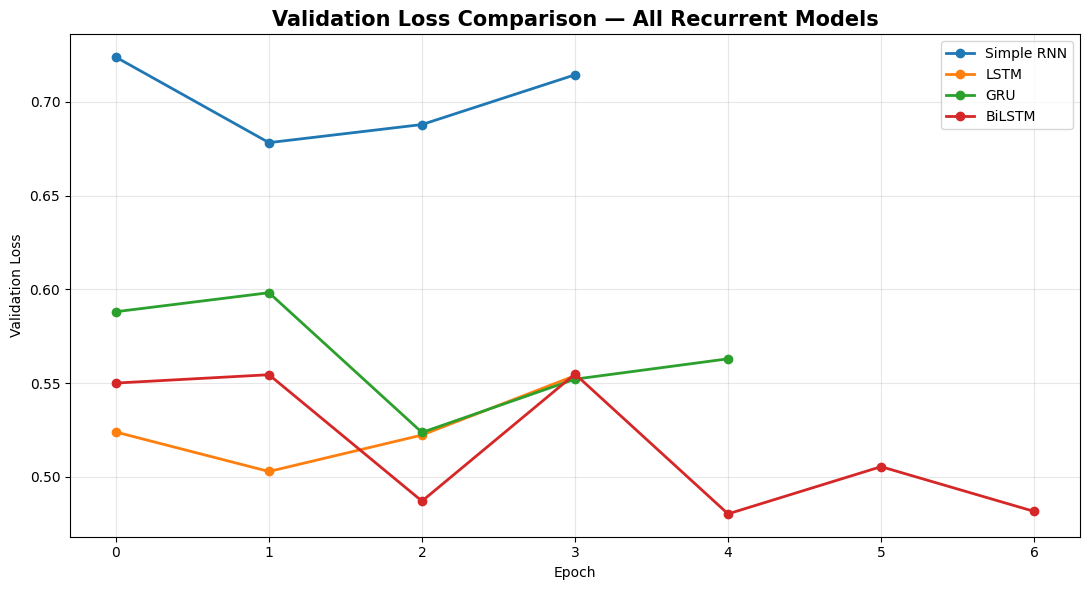

In [64]:
plt.figure(figsize=(11, 6))

plt.plot(
    history_rnn.history["val_loss"],
    marker="o",
    linewidth=2,
    label="Simple RNN"
)

plt.plot(
    history_lstm.history["val_loss"],
    marker="o",
    linewidth=2,
    label="LSTM"
)

plt.plot(
    history_gru.history["val_loss"],
    marker="o",
    linewidth=2,
    label="GRU"
)

plt.plot(
    history_bilstm.history["val_loss"],
    marker="o",
    linewidth=2,
    label="BiLSTM"
)

plt.title(
    "Validation Loss Comparison — All Recurrent Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

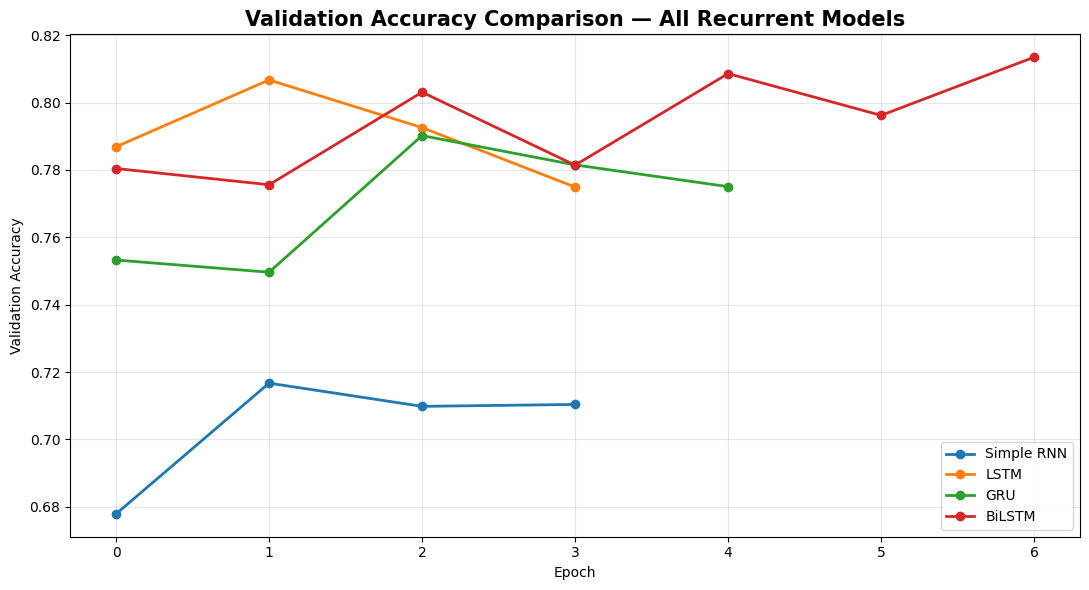

In [67]:
plt.figure(figsize=(11, 6))

plt.plot(
    history_rnn.history["val_accuracy"],
    marker="o",
    linewidth=2,
    label="Simple RNN"
)

plt.plot(
    history_lstm.history["val_accuracy"],
    marker="o",
    linewidth=2,
    label="LSTM"
)

plt.plot(
    history_gru.history["val_accuracy"],
    marker="o",
    linewidth=2,
    label="GRU"
)

plt.plot(
    history_bilstm.history["val_accuracy"],
    marker="o",
    linewidth=2,
    label="BiLSTM"
)

plt.title(
    "Validation Accuracy Comparison — All Recurrent Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [72]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

def evaluate_model(model, X_test, y_test, model_name):
    # Predict probabilities
    y_prob = model.predict(X_test, batch_size=256, verbose=0)
    
    # Convert probabilities to class predictions
    y_pred = np.argmax(y_prob, axis=1)
    
    print("="*60)
    print(model_name)
    print("="*60)
    
    print(f"Accuracy        : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Macro Precision : {precision_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Macro Recall    : {recall_score(y_test, y_pred, average='macro'):.4f}")
    print(f"Macro F1        : {f1_score(y_test, y_pred, average='macro'):.4f}")
    
    print("\n===== Classification Report =====\n")
    # Changed 'label_encoder.classes_' to 'le.classes_' below
    print(classification_report(
        y_test, 
        y_pred, 
        target_names=le.classes_ 
    ))
    
    return y_pred, y_prob

In [73]:
y_pred_rnn, y_prob_rnn = evaluate_model(
    rnn_model,
    X_test_padded,
    y_test,
    "Simple RNN + Frozen CBOW Word2Vec"
)

Simple RNN + Frozen CBOW Word2Vec
Accuracy        : 0.7207
Macro Precision : 0.5793
Macro Recall    : 0.6486
Macro F1        : 0.5768

===== Classification Report =====

              precision    recall  f1-score   support

    Negative       0.62      0.69      0.66      6927
     Neutral       0.15      0.51      0.23      2604
    Positive       0.96      0.75      0.84     30399

    accuracy                           0.72     39930
   macro avg       0.58      0.65      0.58     39930
weighted avg       0.85      0.72      0.77     39930



In [74]:
y_pred_lstm, y_prob_lstm = evaluate_model(
    lstm_model,
    X_test_padded,
    y_test,
    "LSTM + Frozen CBOW Word2Vec"
)

LSTM + Frozen CBOW Word2Vec
Accuracy        : 0.8110
Macro Precision : 0.6492
Macro Recall    : 0.7027
Macro F1        : 0.6521

===== Classification Report =====

              precision    recall  f1-score   support

    Negative       0.77      0.71      0.74      6927
     Neutral       0.22      0.54      0.31      2604
    Positive       0.96      0.86      0.91     30399

    accuracy                           0.81     39930
   macro avg       0.65      0.70      0.65     39930
weighted avg       0.88      0.81      0.84     39930



In [75]:
y_pred_gru, y_prob_gru = evaluate_model(
    gru_model,
    X_test_padded,
    y_test,
    "GRU + Frozen CBOW Word2Vec"
)

GRU + Frozen CBOW Word2Vec
Accuracy        : 0.7944
Macro Precision : 0.6474
Macro Recall    : 0.7143
Macro F1        : 0.6484

===== Classification Report =====

              precision    recall  f1-score   support

    Negative       0.77      0.73      0.75      6927
     Neutral       0.20      0.58      0.30      2604
    Positive       0.97      0.83      0.89     30399

    accuracy                           0.79     39930
   macro avg       0.65      0.71      0.65     39930
weighted avg       0.89      0.79      0.83     39930



In [76]:
y_pred_bilstm, y_prob_bilstm = evaluate_model(
    bilstm_model,
    X_test_padded,
    y_test,
    "BiLSTM + Frozen CBOW Word2Vec"
)

BiLSTM + Frozen CBOW Word2Vec
Accuracy        : 0.8149
Macro Precision : 0.6494
Macro Recall    : 0.7140
Macro F1        : 0.6591

===== Classification Report =====

              precision    recall  f1-score   support

    Negative       0.76      0.75      0.76      6927
     Neutral       0.22      0.54      0.31      2604
    Positive       0.97      0.85      0.91     30399

    accuracy                           0.81     39930
   macro avg       0.65      0.71      0.66     39930
weighted avg       0.88      0.81      0.84     39930



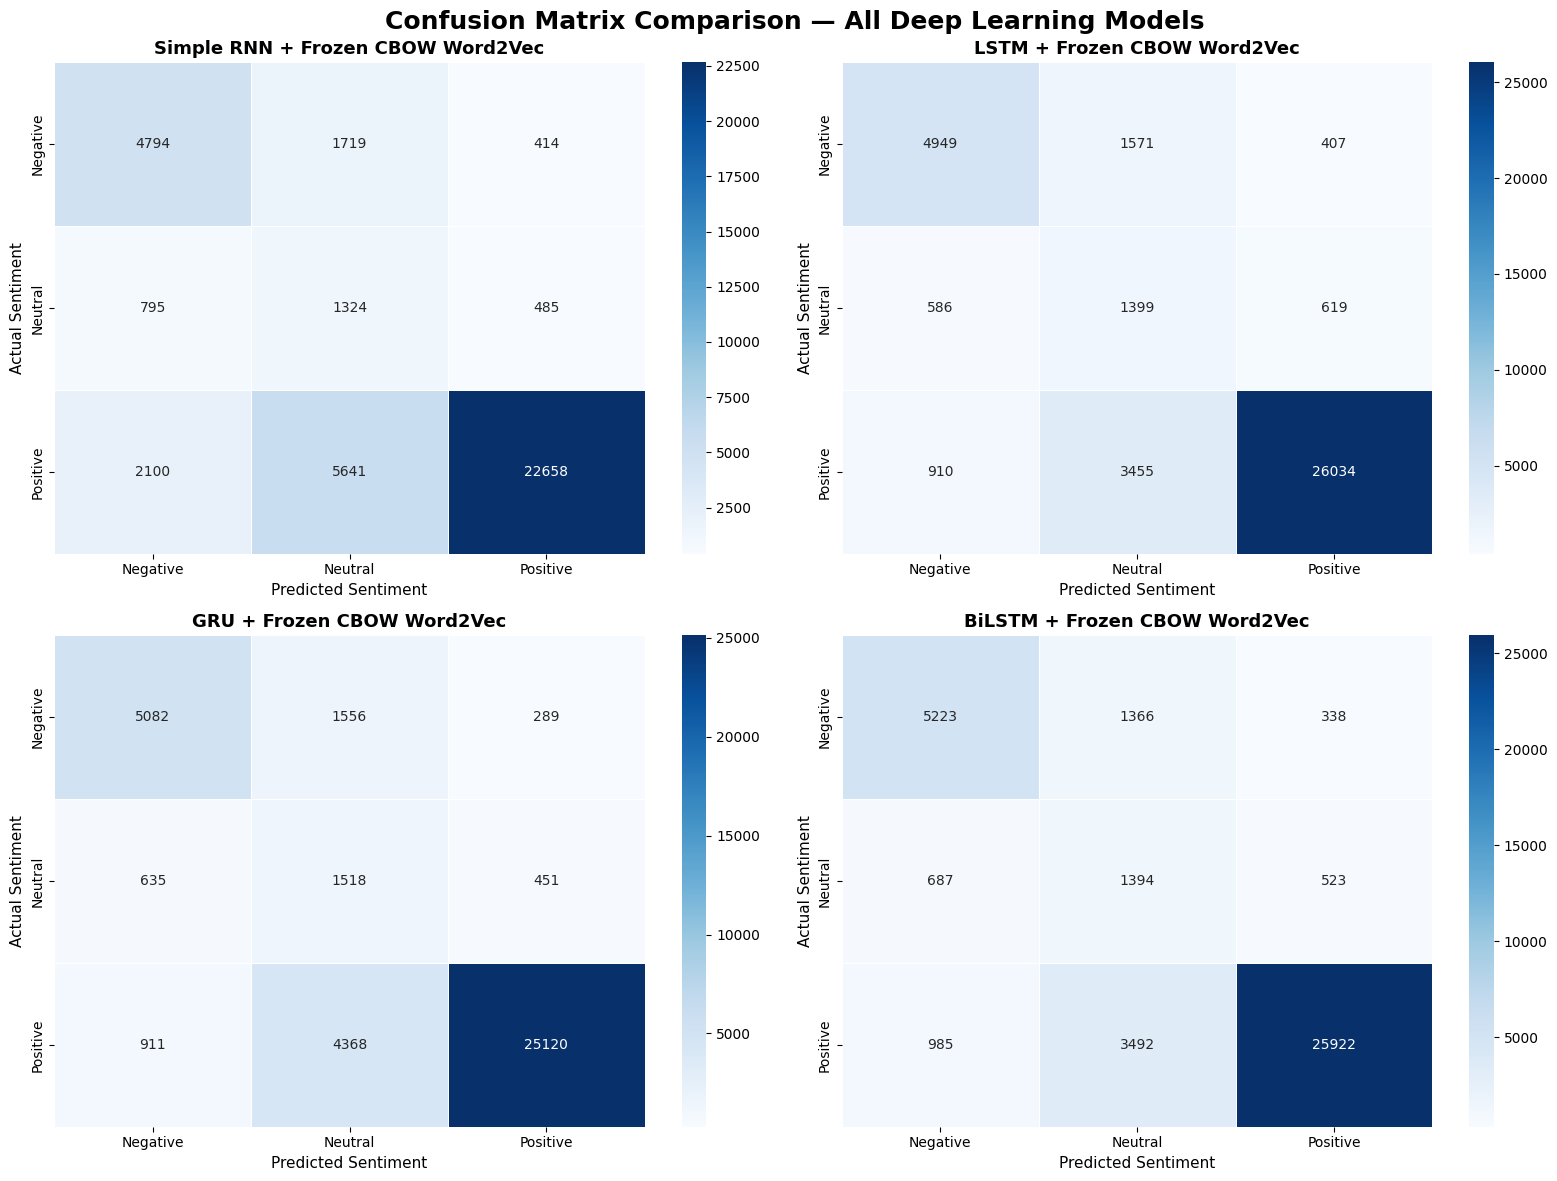

In [82]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Model names and predictions
models_predictions = {
    "Simple RNN + Frozen CBOW Word2Vec": y_pred_rnn,
    "LSTM + Frozen CBOW Word2Vec": y_pred_lstm,
    "GRU + Frozen CBOW Word2Vec": y_pred_gru,
    "BiLSTM + Frozen CBOW Word2Vec": y_pred_bilstm
}

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Flatten axes for easy iteration
axes = axes.flatten()

for ax, (model_name, y_pred) in zip(axes, models_predictions.items()):
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Heatmap
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Blues",
        xticklabels=le.classes_,  # <-- Changed label_encoder to le
        yticklabels=le.classes_,  # <-- Changed label_encoder to le
        cbar=True,
        ax=ax,
        linewidths=0.5,
        linecolor="white"
    )
    ax.set_title(model_name, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted Sentiment", fontsize=11)
    ax.set_ylabel("Actual Sentiment", fontsize=11)

# Overall title
fig.suptitle(
    "Confusion Matrix Comparison — All Deep Learning Models",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [84]:
# BiLSTM + Fine-tuned CBOW Word2Vec

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dropout,
    Dense
)

NUM_CLASSES = 3

bilstm_finetune_model = Sequential([

    Input(shape=(MAX_LEN,)),

    # Start with our pre-trained CBOW Word2Vec embeddings
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        mask_zero=True,        
        trainable=True
    ),

    Bidirectional(
        LSTM(
            128,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

bilstm_finetune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_finetune_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 100)       │     1,672,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,907,767 (7.28 MB)

 Trainable params: 1,907,767 (7.28 MB)

 Non-trainable params: 0 (0.00 B)

In [85]:
early_stopping_bilstm_finetune = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    verbose=1
)

history_bilstm_finetune = bilstm_finetune_model.fit(

    X_train_padded,
    y_train,

    validation_split=0.10,

    epochs=15,

    batch_size=128,

    class_weight=class_weights,

    callbacks=[
        early_stopping_bilstm_finetune
    ],

    verbose=1
)

Epoch 1/15
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 696s 613ms/step - accuracy: 0.7271 - loss: 0.7509 - val_accuracy: 0.7338 - val_loss: 0.6303
Epoch 2/15
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 693s 617ms/step - accuracy: 0.7693 - loss: 0.6756 - val_accuracy: 0.7765 - val_loss: 0.5396
Epoch 3/15
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 690s 613ms/step - accuracy: 0.7834 - loss: 0.6415 - val_accuracy: 0.7960 - val_loss: 0.5115
Epoch 4/15
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 689s 613ms/step - accuracy: 0.7958 - loss: 0.6127 - val_accuracy: 0.7976 - val_loss: 0.5196
Epoch 5/15
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 687s 611ms/step - accuracy: 0.8069 - loss: 0.5857 - val_accuracy: 0.8022 - val_loss: 0.4930
Epoch 6/15
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 681s 606ms/step - accuracy: 0.8168 - loss: 0.5614 - val_accuracy: 0.7827 - val_loss: 0.5462
Epoch 7/15
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 678s 603ms/step - accuracy: 0.8247 - loss: 0.5351 - val_accuracy: 0.8015 - val_loss: 0.5155
Epoch 8/15
1124/1124 ━━━━━━━━━━━━━━━━━━━━ 686s 611ms/step - ac

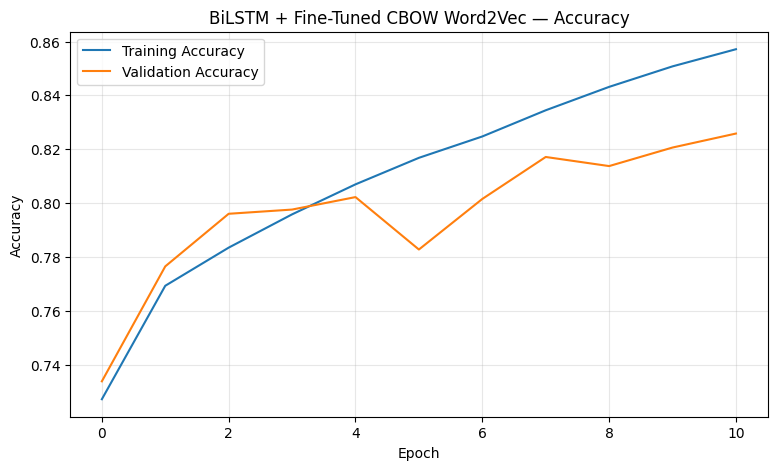

In [88]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_bilstm_finetune.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_bilstm_finetune.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiLSTM + Fine-Tuned CBOW Word2Vec — Accuracy")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [89]:
y_pred_bilstm_finetune, y_prob_bilstm_finetune = evaluate_model(

    bilstm_finetune_model,

    X_test_padded,

    y_test,

    "BiLSTM + Fine-Tuned CBOW Word2Vec"
)

BiLSTM + Fine-Tuned CBOW Word2Vec
Accuracy        : 0.8153
Macro Precision : 0.6482
Macro Recall    : 0.7086
Macro F1        : 0.6563

===== Classification Report =====

              precision    recall  f1-score   support

    Negative       0.76      0.74      0.75      6927
     Neutral       0.22      0.53      0.31      2604
    Positive       0.97      0.86      0.91     30399

    accuracy                           0.82     39930
   macro avg       0.65      0.71      0.66     39930
weighted avg       0.88      0.82      0.84     39930



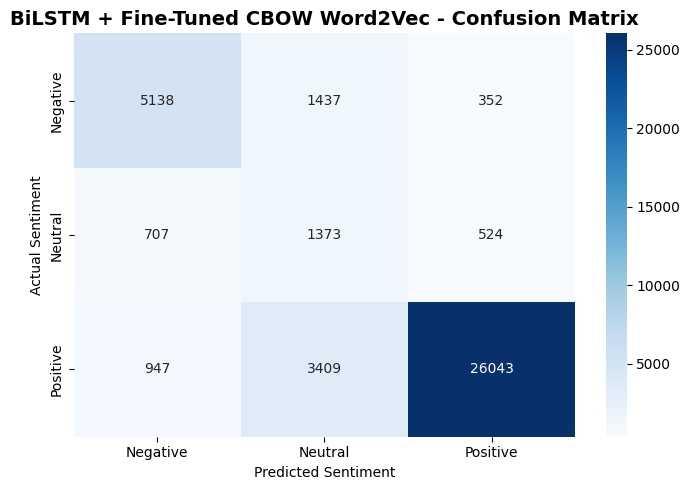

In [90]:
plot_confusion_matrix(

    y_test,

    y_pred_bilstm_finetune,

    "BiLSTM + Fine-Tuned CBOW Word2Vec"
)

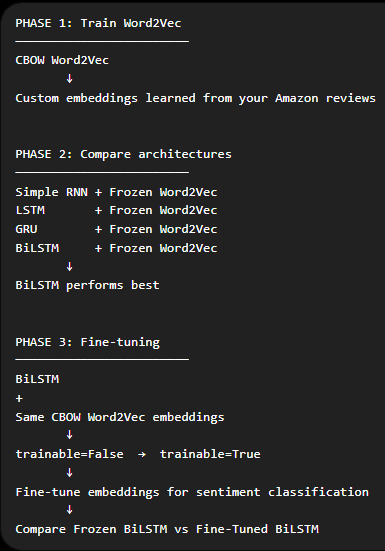

# **ROC_AUC,PR_AUC**

In [91]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, average_precision_score

# Convert true labels into one-hot/binary format
y_test_bin = label_binarize(
    y_test,
    classes=[0, 1, 2]
)

# ============================
# ROC-AUC
# ============================

roc_auc_macro = roc_auc_score(
    y_test_bin,
    y_prob_bilstm_finetune,
    multi_class="ovr",
    average="macro"
)

# ============================
# PR-AUC
# ============================

pr_auc_macro = average_precision_score(
    y_test_bin,
    y_prob_bilstm_finetune,
    average="macro"
)

print("ROC-AUC (Macro):", round(roc_auc_macro, 4))
print("PR-AUC  (Macro):", round(pr_auc_macro, 4))

ROC-AUC (Macro): 0.9129
PR-AUC  (Macro): 0.6859


In [93]:
from sklearn.metrics import roc_auc_score

# Changed label_encoder to le
class_names = le.classes_ 

roc_auc_per_class = roc_auc_score(
    y_test_bin, 
    y_prob_bilstm_finetune, 
    multi_class="ovr", 
    average=None
)

for class_name, score in zip(class_names, roc_auc_per_class):
    print(f"{class_name} ROC-AUC: {score:.4f}")

Negative ROC-AUC: 0.9569
Neutral ROC-AUC: 0.8284
Positive ROC-AUC: 0.9535


In [94]:
from sklearn.metrics import average_precision_score

pr_auc_per_class = average_precision_score(
    y_test_bin,
    y_prob_bilstm_finetune,
    average=None
)

for class_name, score in zip(class_names, pr_auc_per_class):
    print(f"{class_name} PR-AUC: {score:.4f}")

Negative PR-AUC: 0.8346
Neutral PR-AUC: 0.2398
Positive PR-AUC: 0.9833


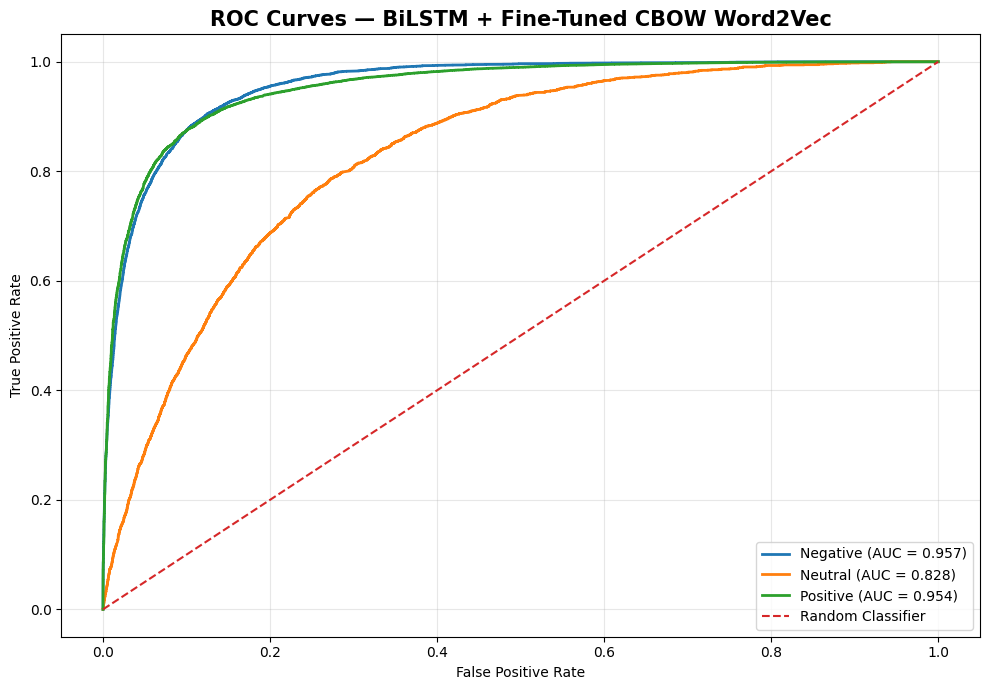

In [95]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob_bilstm_finetune[:, i]
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {roc_auc_per_class[i]:.3f})"
    )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.title(
    "ROC Curves — BiLSTM + Fine-Tuned CBOW Word2Vec",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

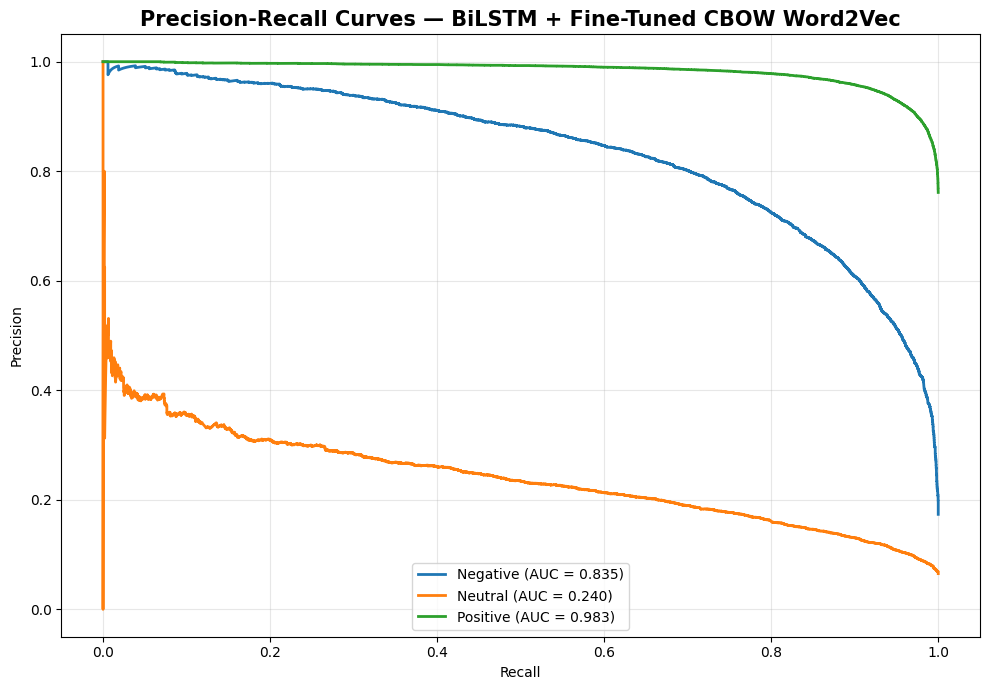

In [96]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10, 7))

for i, class_name in enumerate(class_names):

    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_prob_bilstm_finetune[:, i]
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{class_name} (AUC = {pr_auc_per_class[i]:.3f})"
    )

plt.title(
    "Precision-Recall Curves — BiLSTM + Fine-Tuned CBOW Word2Vec",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [97]:
# Frozen BiLSTM

roc_auc_frozen = roc_auc_score(
    y_test_bin,
    y_prob_bilstm,
    multi_class="ovr",
    average="macro"
)

pr_auc_frozen = average_precision_score(
    y_test_bin,
    y_prob_bilstm,
    average="macro"
)


# Fine-tuned BiLSTM

roc_auc_finetuned = roc_auc_score(
    y_test_bin,
    y_prob_bilstm_finetune,
    multi_class="ovr",
    average="macro"
)

pr_auc_finetuned = average_precision_score(
    y_test_bin,
    y_prob_bilstm_finetune,
    average="macro"
)


print("===== BiLSTM Comparison =====")

print(f"\nFrozen Word2Vec")
print(f"ROC-AUC : {roc_auc_frozen:.4f}")
print(f"PR-AUC  : {pr_auc_frozen:.4f}")

print(f"\nFine-Tuned Word2Vec")
print(f"ROC-AUC : {roc_auc_finetuned:.4f}")
print(f"PR-AUC  : {pr_auc_finetuned:.4f}")

===== BiLSTM Comparison =====

Frozen Word2Vec
ROC-AUC : 0.9146
PR-AUC  : 0.6883

Fine-Tuned Word2Vec
ROC-AUC : 0.9129
PR-AUC  : 0.6859


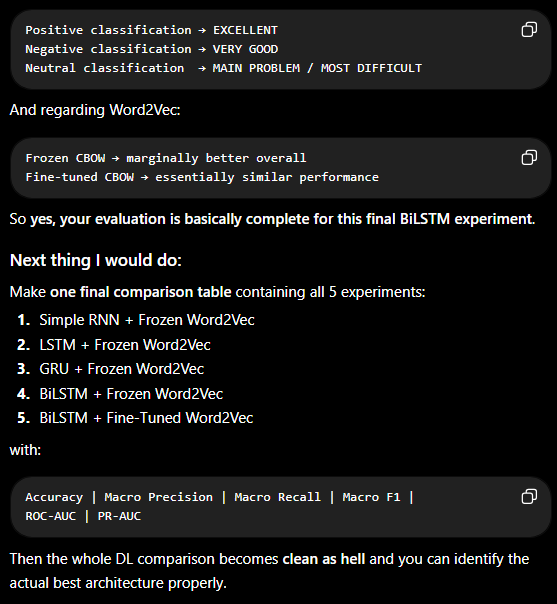